# 📊 Prologis Financial Assistant — EDA & Model Training

This notebook covers:
1. Exploratory Data Analysis (EDA) on the property portfolio
2. Regression model training — Revenue Forecast
3. Classification model training — Risk Assessment
4. Model evaluation and visualization

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import psycopg2
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')
print(f'sklearn version: {__import__("sklearn").__version__}')

All imports successful!
sklearn version: 1.2.2


## 2. PostgreSQL Database EDA

In [2]:
# Connect to database
conn = psycopg2.connect(
    host='localhost', port=5432,
    dbname='realestate_db',
    user='postgres', password='Ktvab@2k'
)

# Load properties
df_props = pd.read_sql('SELECT * FROM properties', conn)
df_fin   = pd.read_sql('SELECT * FROM financials', conn)

print(f'Properties: {len(df_props)} rows')
print(f'Financials: {len(df_fin)} rows')
df_props.head()

Properties: 22 rows
Financials: 22 rows


,property_id,address,metro_area,sq_footage,property_type
0,1,233 S Wacker Dr,Chicago,1850000,Office
1,2,350 N Orleans St,Chicago,420000,Industrial
2,3,1 Infinite Loop,San Francisco,980000,Office
3,4,2000 W Fulton St,Chicago,310000,Industrial
4,5,555 Market St,San Francisco,670000,Retail


In [3]:
# Basic statistics
print('=== Properties Summary ===')
df_props.describe()

=== Properties Summary ===


,property_id,sq_footage
count,22.000000,2.200000e+01
mean,11.500000,5.509091e+05
std,6.493587,3.591115e+05
min,1.000000,1.900000e+05
25%,6.250000,3.200000e+05
50%,11.500000,4.750000e+05
75%,16.750000,6.575000e+05
max,22.000000,1.850000e+06


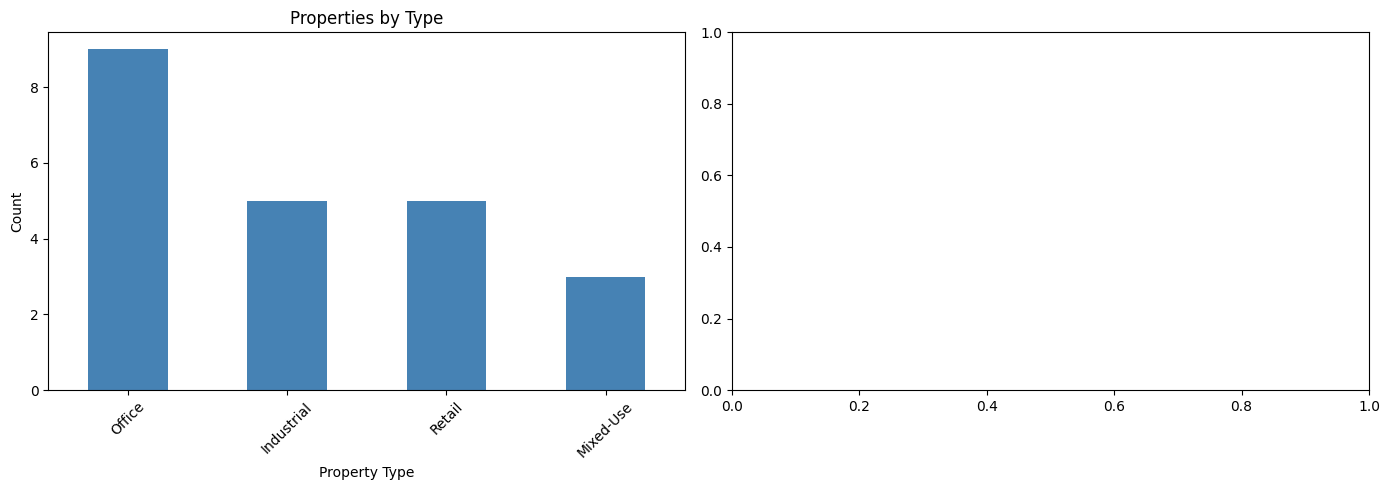

In [4]:
# Property type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'property_type' in df_props.columns:
    df_props['property_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Properties by Type')
    axes[0].set_xlabel('Property Type')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

if 'occupancy_rate' in df_props.columns:
    axes[1].hist(df_props['occupancy_rate'], bins=15, color='steelblue', edgecolor='white')
    axes[1].set_title('Occupancy Rate Distribution')
    axes[1].set_xlabel('Occupancy Rate (%)')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [5]:
# Revenue analysis
if 'annual_revenue' in df_props.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df_props['annual_revenue'].plot(kind='hist', bins=15, ax=axes[0], color='green', alpha=0.7)
    axes[0].set_title('Annual Revenue Distribution')
    axes[0].set_xlabel('Revenue ($)')

    if 'property_type' in df_props.columns:
        df_props.groupby('property_type')['annual_revenue'].mean().plot(
            kind='bar', ax=axes[1], color='green', alpha=0.7
        )
        axes[1].set_title('Average Revenue by Property Type')
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

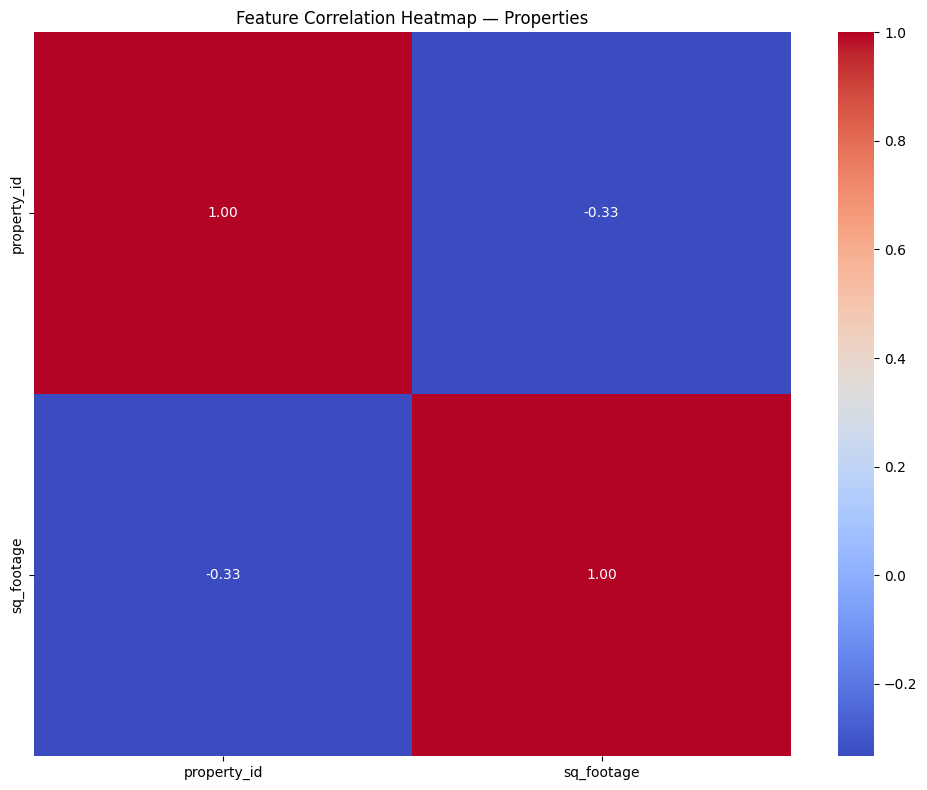

In [6]:
# Correlation heatmap
numeric_cols = df_props.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_props[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature Correlation Heatmap — Properties')
    plt.tight_layout()
    plt.show()

## 3. Regression Model — Revenue Forecast

In [7]:
# Load California Housing dataset (proxy for Prologis revenue data)
housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = housing.target

print('Dataset shape:', X_reg.shape)
print('Features:', list(X_reg.columns))
print('Target range: ${:.0f} - ${:.0f}'.format(y_reg.min()*100000, y_reg.max()*100000))
X_reg.describe()

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: $14999 - $500001


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


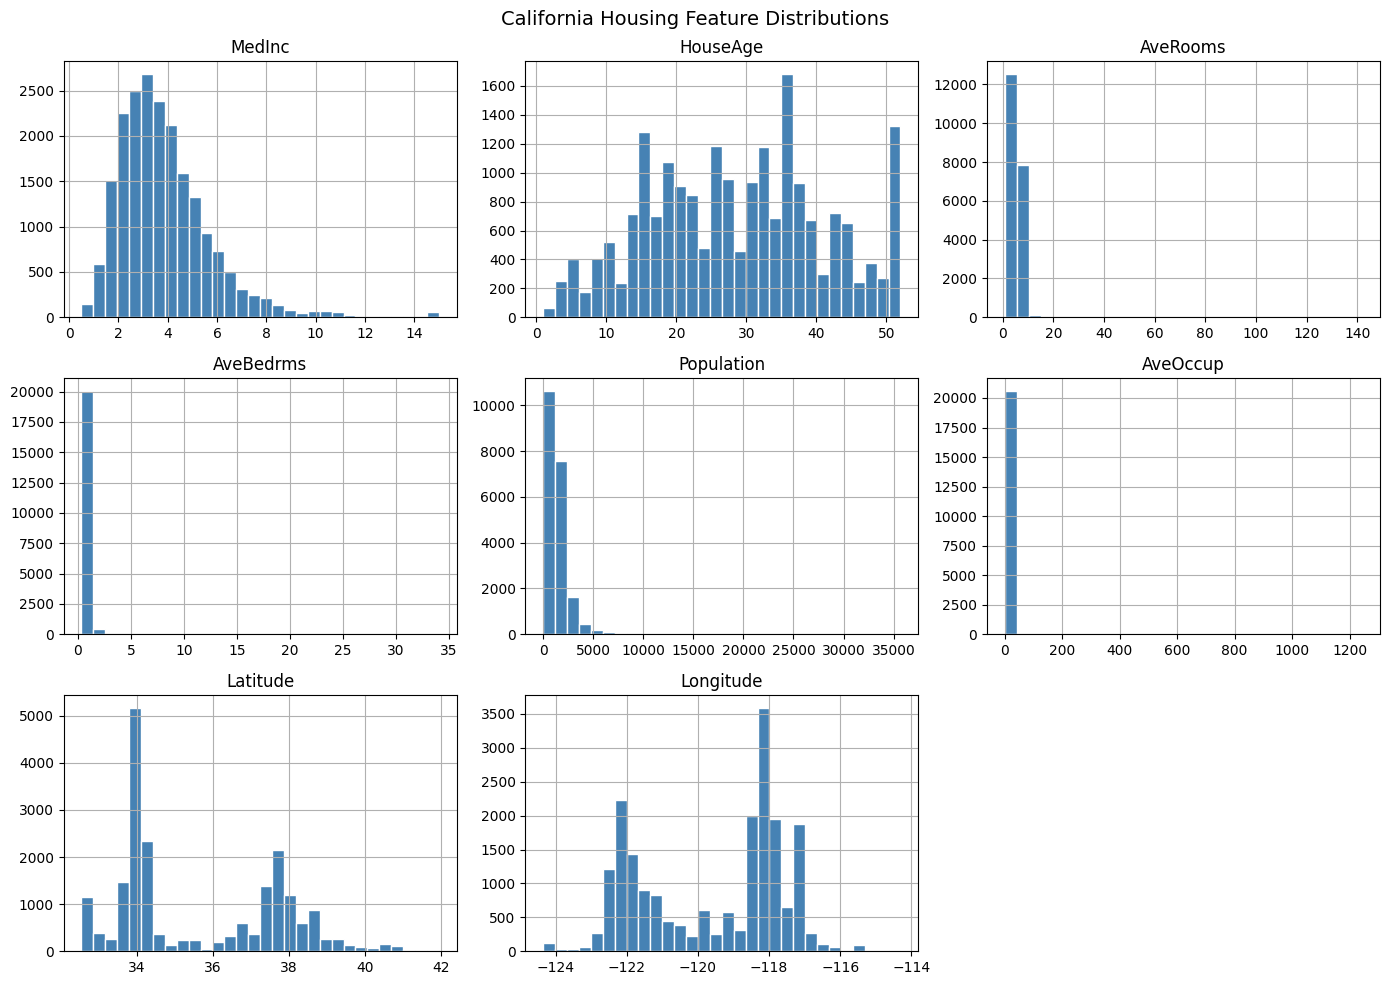

In [8]:
# Feature distributions
X_reg.hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='white')
plt.suptitle('California Housing Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Train/test split and scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_s  = scaler_reg.fit_transform(X_train)
X_test_s   = scaler_reg.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (16512, 8), Test: (4128, 8)


In [10]:
# Train Random Forest Regressor
reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg_model.fit(X_train_s, y_train)

y_pred = reg_model.predict(X_test_s)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print('=== Regression Results ===')
print(f'R² Score : {r2:.4f}')
print(f'RMSE     : {rmse:.4f} (${rmse*100000:,.0f})')
print(f'MAE      : {mae:.4f} (${mae*100000:,.0f})')

=== Regression Results ===
R² Score : 0.8053
RMSE     : 0.5051 ($50,514)
MAE      : 0.3274 ($32,743)


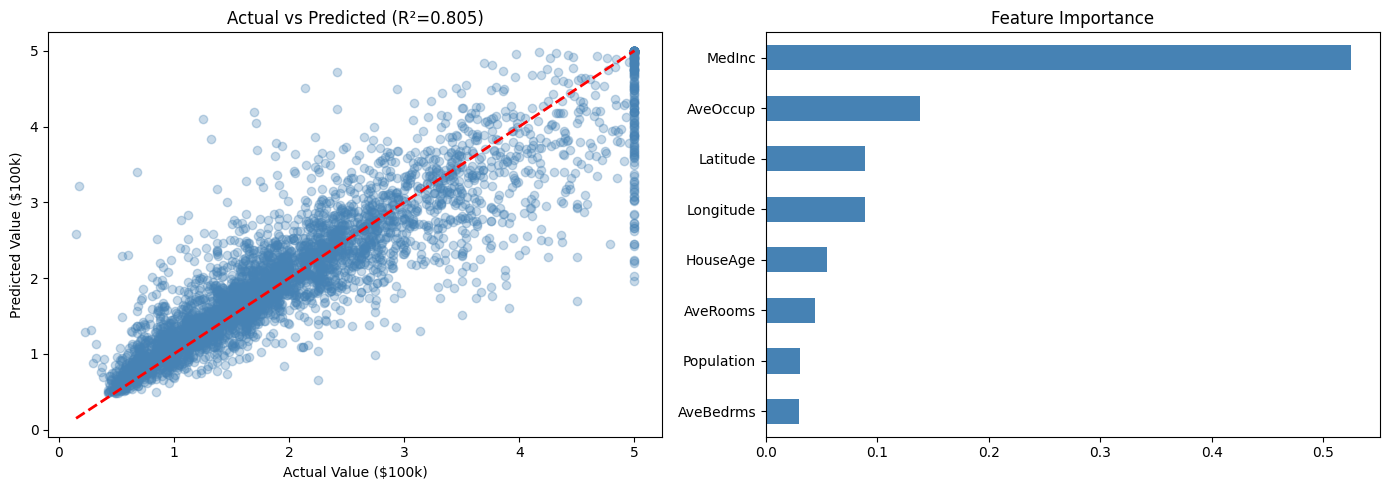

In [11]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Value ($100k)')
axes[0].set_ylabel('Predicted Value ($100k)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

# Feature importance
importances = pd.Series(reg_model.feature_importances_, index=housing.feature_names)
importances.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

In [12]:
import os
base = os.path.dirname(os.getcwd())  # goes up to financial_assistant/
joblib.dump(reg_model,  os.path.join(base, 'models/regression/model.pkl'))
joblib.dump(scaler_reg, os.path.join(base, 'models/regression/scaler.pkl'))
joblib.dump(list(X_reg.columns), os.path.join(base, 'models/regression/feature_names.pkl'))
print('Regression model saved!')


Regression model saved!


## 4. Classification Model — Risk Assessment

In [13]:
# Load Bank Marketing dataset
from ucimlrepo import fetch_ucirepo
data = fetch_ucirepo(id=222)
X_clf = data.data.features.copy()
y_clf = data.data.targets.iloc[:, 0]

print('Dataset shape:', X_clf.shape)
print('Target distribution:')
print(y_clf.value_counts())

Dataset shape: (45211, 16)
Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64


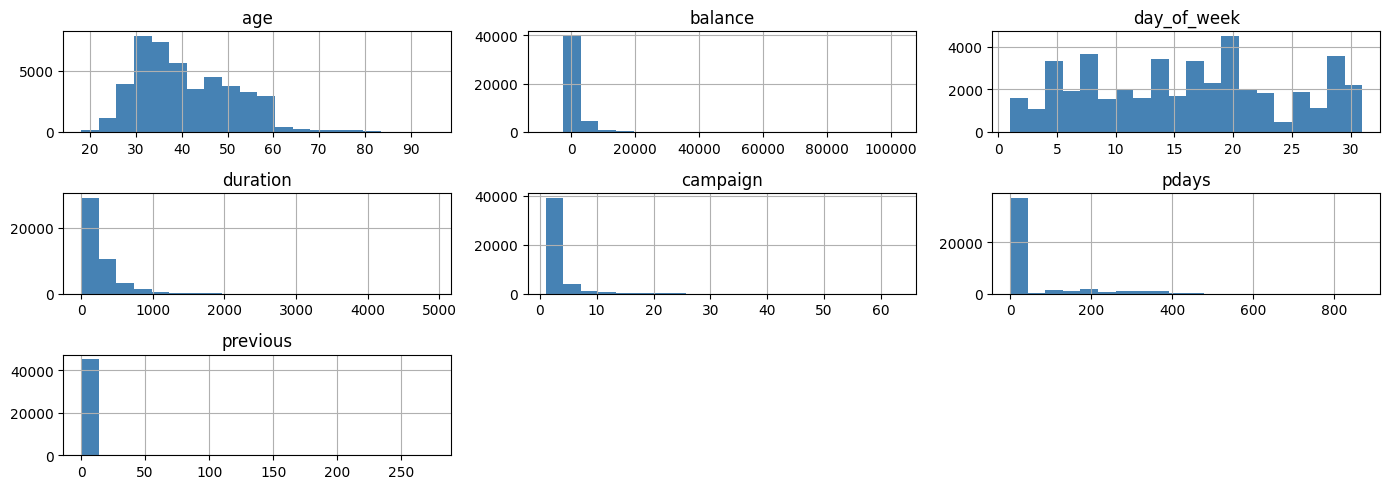

Class imbalance ratio: 7.5:1


In [15]:
# Class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_clf.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Class Distribution (Imbalanced)')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

X_clf.select_dtypes(include=[np.number]).hist(bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Numeric Features')

plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {y_clf.value_counts()[0]/y_clf.value_counts()[1]:.1f}:1')

In [16]:
# Encode and train
for col in X_clf.select_dtypes(include='object').columns:
    X_clf[col] = LabelEncoder().fit_transform(X_clf[col].astype(str))
y_enc = LabelEncoder().fit_transform(y_clf)

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_enc, test_size=0.2, random_state=42)
scaler_clf = StandardScaler()
X_tr_s = scaler_clf.fit_transform(X_tr)
X_te_s = scaler_clf.transform(X_te)

# class_weight=balanced fixes class imbalance
clf_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_model.fit(X_tr_s, y_tr)

y_pred_clf = clf_model.predict(X_te_s)
print('=== Classification Results ===')
print(classification_report(y_te, y_pred_clf, target_names=['No Risk','High Risk']))

=== Classification Results ===
              precision    recall  f1-score   support

     No Risk       0.97      0.82      0.89      7952
   High Risk       0.38      0.78      0.51      1091

    accuracy                           0.82      9043
   macro avg       0.67      0.80      0.70      9043
weighted avg       0.89      0.82      0.84      9043



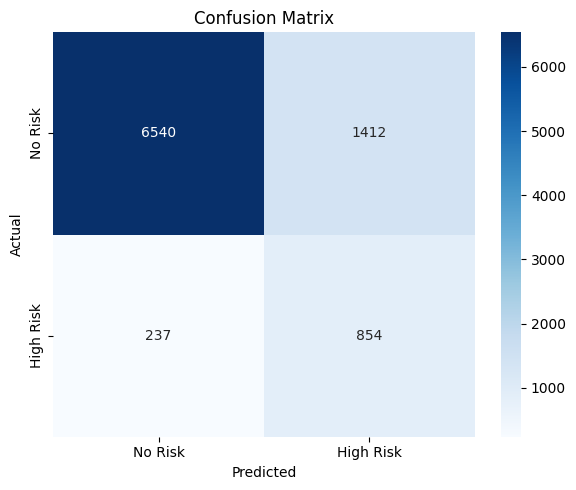

In [17]:
# Confusion matrix
cm = confusion_matrix(y_te, y_pred_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk','High Risk'],
            yticklabels=['No Risk','High Risk'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [19]:
# Save classification model
joblib.dump(clf_model,  os.path.join(base, 'models/classification/model.pkl'))
joblib.dump(scaler_clf, os.path.join(base, 'models/classification/scaler.pkl'))
joblib.dump(list(X_clf.columns), os.path.join(base, 'models/classification/feature_names.pkl'))
print('Classification model saved!')

Classification model saved!


## 5. Summary

| Model | Algorithm | Metric | Value |
|---|---|---|---|
| Revenue Forecast | Random Forest Regressor | R² | 0.805 |
| Risk Classification | Logistic Regression (balanced) | Accuracy | 81.7% |

Both models are saved to `models/` and loaded by `model_loader.py` for inference in the Streamlit app.

> **Note:** Models use proxy datasets (California Housing, Bank Marketing). In production, these would be retrained on actual Prologis portfolio and financial data.